In [1]:
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.12.0+cu126
CUDA Available: True
CUDA Version: 12.6
GPU Name: NVIDIA RTX 4000 Ada Generation


In [2]:
# ============================================================
# Step 1 — Environment, Imports, Reproducibility, and Runtime Setup
# Target Architecture: DeepLabv3+ (Encoder-Decoder with ASPP)
# Target Backbone: ResNet-101
# Target Dataset: KITTI Semantic
# Optimization Mode: ABLATION STUDY - NO BACKBONE FREEZING (AB1)
# ============================================================

import os
import cv2
import gc
import math
import glob
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Strict CUDA memory behavior to prevent fragmentation on 16GB/24GB VRAM
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Schedulers & Data Loading
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import Dataset, DataLoader

# VRAM Optimization Tools (AMP & Checkpointing)
from torch.amp import GradScaler, autocast
from torch.utils.checkpoint import checkpoint 

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm
from sklearn.metrics import confusion_matrix

# --------------------------------------------------
# Cleanup and warning control
# --------------------------------------------------
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

warnings.filterwarnings("ignore", category=UserWarning)

# --------------------------------------------------
# Reproducibility Setup
# --------------------------------------------------
SEED = 42

def set_seed(seed: int = 42, deterministic: bool = False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            pass
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

set_seed(SEED, deterministic=False)
print(f"Seed set to {SEED} (deterministic=False for stable/efficient training)")

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# --------------------------------------------------
# Matplotlib & Seaborn Styling Setup
# --------------------------------------------------
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")
sns.set_context("talk", font_scale=0.9)

# --------------------------------------------------
# Device & Engine Configuration
# --------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Toolchain Version: {torch.version.cuda}")
    print(f"Total Available GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

if torch.cuda.is_available():
    try:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        print("TF32 matrix operations enabled successfully.")
    except Exception as e:
        print(f"TF32 configuration skipped: {e}")

# --------------------------------------------------
# AMP Setup
# --------------------------------------------------
USE_AMP = torch.cuda.is_available()
scaler = GradScaler("cuda" if torch.cuda.is_available() else "cpu", enabled=USE_AMP)
print(f"Mixed Precision Training Enabled: {USE_AMP}")

# --------------------------------------------------
# CENTRALIZED DIRECTORY & PATH MAPPING
# --------------------------------------------------
# 1. Dataset Roots 
KITTI_ROOT = Path("/home/ubuntu/miniconda3/envs/foggy/Dataset/KITTI").expanduser()
TRAIN_DIR = KITTI_ROOT / "training"
TEST_DIR = KITTI_ROOT / "testing"

# Standard KITTI Semantic Segmentation paths for images and masks
IMG_ROOT = TRAIN_DIR / "image_2"
MASK_ROOT = TRAIN_DIR / "semantic"

# 2. Main Output Root for KITTI Ablation Study
OUTPUT_DIR = Path("~/Pictures/deeplabv3+_kitti").expanduser()

FINAL_SAVE_DIR = OUTPUT_DIR / "Results_Export_deeplabv3+_kitti"
QUAL_VIS_DIR = OUTPUT_DIR / "training_visuals_deeplabv3+_kitti"

# 3. Local Working Directories
CHECKPOINT_DIR = OUTPUT_DIR / "progressive_checkpoints_deeplabv3+_kitti"
PLOTS_DIR = OUTPUT_DIR / "training_plots_deeplabv3+_kitti"
LOGS_DIR = OUTPUT_DIR / "training_logs_deeplabv3+_kitti"
METRICS_DIR = OUTPUT_DIR / "training_metrics_deeplabv3+_kitti"

# Safely build all target directories
for d in [OUTPUT_DIR, CHECKPOINT_DIR, PLOTS_DIR, LOGS_DIR, METRICS_DIR, FINAL_SAVE_DIR, QUAL_VIS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Model Specifications
# --------------------------------------------------
MODEL_NAME = "DeepLabv3+ (ResNet-101 Backbone)"
MODEL_ALIAS = "DeepLabv3+ KITTI (NO BACKBONE FREEZING)"

print(f"\nModel Configuration Linked: {MODEL_ALIAS}")
print(f"Custom Architecture Base: {MODEL_NAME}")
print(f"Global Analytical Results Save Path Linked: {FINAL_SAVE_DIR.resolve()}")
print(f"Checkpoints will be saved to: {CHECKPOINT_DIR.resolve()}")

# --------------------------------------------------
# Runtime Performance Containers
# --------------------------------------------------
history = {
    "epoch": [],
    "phase": [],
    # Training Loop Loss Tracking
    "train_total_loss": [],
    "train_ce_loss": [],
    "train_miou": [],    
    "train_macc": [],    
    "train_aacc": [],    
    # Validation Evaluation Metrics
    "val_total_loss": [], 
    "val_ce_loss": [],
    "val_miou": [],
    "val_macc": [],
    "val_aacc": [],
    # Optimizer State Records
    "backbone_lr": [],
    "head_lr": [],
    "epoch_time_sec": []
}

best_record = {
    "epoch": -1,
    "best_epoch": -1,
    "best_miou": -1.0,
    "best_macc": -1.0,
    "best_aacc": -1.0,
    "best_path": str(CHECKPOINT_DIR / "best_miou_deeplabv3plus_checkpoint.pt"),
    "latest_path": str(CHECKPOINT_DIR / "latest_deeplabv3plus_checkpoint.pt")
}

print("Metrics tracking layers constructed. Global paths centralized. Step 1 initialization sequence completed.")

Seed set to 42 (deterministic=False for stable/efficient training)
Using Device: cuda
GPU Model: NVIDIA RTX 4000 Ada Generation
CUDA Toolchain Version: 12.6
Total Available GPU Memory: 19.67 GB
TF32 matrix operations enabled successfully.
Mixed Precision Training Enabled: True

Model Configuration Linked: DeepLabv3+ KITTI (NO BACKBONE FREEZING)
Custom Architecture Base: DeepLabv3+ (ResNet-101 Backbone)
Global Analytical Results Save Path Linked: /home/ubuntu/Pictures/deeplabv3+_kitti/Results_Export_deeplabv3+_kitti
Checkpoints will be saved to: /home/ubuntu/Pictures/deeplabv3+_kitti/progressive_checkpoints_deeplabv3+_kitti
Metrics tracking layers constructed. Global paths centralized. Step 1 initialization sequence completed.


In [3]:
# ============================================================
# STEP 2: HYPERPARAMETERS, LABEL ENCODING, VISUALIZATION
# Target Architecture: DeepLabv3+ (Encoder-Decoder)
# Target Dataset: KITTI Semantic
# Optimization Mode: Strict Paper Reproduction
# ============================================================

print(f"Image root inherited: {IMG_ROOT}")
print(f"Mask root inherited : {MASK_ROOT}")
print(f"Visualizations target: {QUAL_VIS_DIR.resolve()}")
print(f"Final export target: {FINAL_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# CORE TASK SETTINGS (KITTI evaluates on the same 19 Cityscapes classes)
# ------------------------------------------------------------
CLASSES = 19
IGNORE_INDEX = 255
USE_LABEL_TRAINIDS = True

CLASS_NAMES = [
    "Road", "Sidewalk", "Building", "Wall", "Fence", "Pole",
    "Traffic Light", "Traffic Sign", "Vegetation", "Terrain", "Sky",
    "Person", "Rider", "Car", "Truck", "Bus", "Train", "Motorcycle", "Bicycle"
]

# Standard RGB Color Palette (Matches Cityscapes for seamless transfer/evaluation)
KITTI_PALETTE = np.array([
    [128, 64, 128],   # Road
    [244, 35, 232],   # Sidewalk
    [70, 70, 70],     # Building
    [102, 102, 156],  # Wall
    [190, 153, 153],  # Fence
    [153, 153, 153],  # Pole
    [250, 170, 30],   # Traffic Light
    [220, 220, 0],    # Traffic Sign
    [107, 142, 35],   # Vegetation
    [152, 251, 152],  # Terrain
    [70, 130, 180],   # Sky
    [220, 20, 60],    # Person
    [255, 0, 0],      # Rider
    [0, 0, 142],      # Car
    [0, 0, 70],       # Truck
    [0, 60, 100],     # Bus
    [0, 80, 100],     # Train
    [0, 0, 230],      # Motorcycle
    [119, 11, 32]     # Bicycle
], dtype=np.uint8)

# ------------------------------------------------------------
# DEEPLABV3+ OPTIMIZATION SCHEDULE 
# ------------------------------------------------------------
BASE_LR = 0.007               
LR_POLICY = "poly"            
WEIGHT_DECAY = 4e-5           
MOMENTUM = 0.9                

# Adjusted for KITTI's native aspect ratio (~375x1242)
TRAIN_CROP_SIZE = (369, 513)  
BATCH_SIZE = 16               
GRAD_ACCUM_STEPS = 1          

# Increased from 120 to 200 to account for KITTI's significantly smaller training volume
EPOCHS = 200

# Output Stride controls feature map resolution. OS=16 strikes the best balance of speed/accuracy.
TRAIN_OUTPUT_STRIDE = 16 
FREEZE_BATCHNORM_STATS = False 

print("\n--- DEEPLABV3+ TRAINING CONFIGURATION ---")
print(f"Total Training Epochs  : {EPOCHS}")
print(f"Base Learning Rate     : {BASE_LR}")
print(f"Learning Rate Schedule : {LR_POLICY} policy")
print(f"Weight Decay           : {WEIGHT_DECAY}")
print(f"Training Crop Size     : {TRAIN_CROP_SIZE}")
print(f"Output Stride (Train)  : {TRAIN_OUTPUT_STRIDE}")
print(f"Batch Norm Fine-tuning : {not FREEZE_BATCHNORM_STATS}")

# ------------------------------------------------------------
# SCHEDULER / LOSS SETTINGS
# ------------------------------------------------------------
USE_CROSS_ENTROPY = True

print("\n--- Loss Formulation ---")
print("Using Standard Cross-Entropy Loss (DeepLabv3+ specification)")

# ------------------------------------------------------------
# VALIDATION / INFERENCE SETTINGS
# ------------------------------------------------------------
EVAL_OUTPUT_STRIDE = 16          
USE_MULTI_SCALE_INFERENCE = True 
USE_FLIP_TTA = True              

print("\n--- Evaluation Strategy ---")
print(f"Output Stride (Eval)       : {EVAL_OUTPUT_STRIDE}")
print(f"Multi-Scale Inference (MS) : {USE_MULTI_SCALE_INFERENCE}")
print(f"Left-Right Flipping (Flip) : {USE_FLIP_TTA}")

# ------------------------------------------------------------
# 34 -> 19 LABEL MAPPING & ENCODING (Retained for KITTI mapping)
# ------------------------------------------------------------
mapping_34_to_19 = {
    0: 255, 1: 255, 2: 255, 3: 255, 4: 255, 5: 255, 6: 255,
    7: 0, 8: 1, 9: 255, 10: 255, 11: 2, 12: 3, 13: 4,
    14: 255, 15: 255, 16: 255, 17: 5, 18: 255, 19: 6, 20: 7,
    21: 8, 22: 9, 23: 10, 24: 11, 25: 12, 26: 13, 27: 14,
    28: 15, 29: 255, 30: 255, 31: 16, 32: 17, 33: 18, -1: 255
}

LABEL_LUT = np.full(256, IGNORE_INDEX, dtype=np.uint8)
for k, v in mapping_34_to_19.items():
    if 0 <= k <= 255:
        LABEL_LUT[k] = v

def encode_mask(mask: np.ndarray) -> np.ndarray:
    uniq = np.unique(mask)
    if uniq.max() <= 255 and np.all(np.isin(uniq, list(range(CLASSES)) + [IGNORE_INDEX])):
        return mask.astype(np.uint8)
    encoded = LABEL_LUT[mask.clip(0, 255)]
    return encoded.astype(np.uint8)

def decode_segmap(segmentation_map: np.ndarray) -> np.ndarray:
    h, w = segmentation_map.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    valid_mask = (segmentation_map >= 0) & (segmentation_map < CLASSES)
    for label, color in enumerate(KITTI_PALETTE):
        rgb[segmentation_map == label] = color
    rgb[~valid_mask] = np.array([0, 0, 0], dtype=np.uint8)
    return rgb

# ------------------------------------------------------------
# PUBLICATION-READY EVALUATION CURVES 
# ------------------------------------------------------------
def plot_training_curves(history_dict, save_path):
    epochs = history_dict["epoch"]
    if len(epochs) == 0: return

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Total Loss Curve
    if len(history_dict.get("train_total_loss", [])) == len(epochs):
        axes[0].plot(epochs, history_dict["train_total_loss"], label='Train Total Loss', color='blue', linewidth=2)
    val_loss_arr = np.array(history_dict.get("val_total_loss", []))
    if len(val_loss_arr) == len(epochs) and not np.isnan(val_loss_arr).all() and not np.all(val_loss_arr == 0):
        axes[0].plot(epochs, val_loss_arr, label='Validation Loss', color='red', linewidth=2)
    axes[0].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epochs', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(fontsize=12)

    # Plot 2: mIoU Curve (Formatted as percentage)
    if len(history_dict.get("train_miou", [])) == len(epochs):
        axes[1].plot(epochs, history_dict["train_miou"], label='Train mIoU', color='green', linewidth=2)
    if len(history_dict.get("val_miou", [])) == len(epochs):
        axes[1].plot(epochs, history_dict["val_miou"], label='Validation mIoU', color='orange', linewidth=2)
    
    axes[1].set_title('Training vs Validation mIoU', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epochs', fontsize=12)
    axes[1].set_ylabel('mIoU (%)', fontsize=12)
    axes[1].legend(fontsize=12)

    plt.tight_layout()
    # Forces global save directory routing
    plt.savefig(FINAL_SAVE_DIR / save_path.name if isinstance(save_path, Path) else FINAL_SAVE_DIR / Path(save_path).name, dpi=600, bbox_inches="tight")
    plt.close()

# ------------------------------------------------------------
# QUALITATIVE VISUALIZATION
# ------------------------------------------------------------
def visualize_results(loader, model, epoch, save_path=QUAL_VIS_DIR, max_images=3):
    save_path = Path(save_path)
    save_path.mkdir(parents=True, exist_ok=True)
    model.eval()

    batch = next(iter(loader))
    
    images, target_masks = batch[0], batch[1]
    images = images.to(DEVICE)
    _, _, current_h, current_w = images.shape

    with torch.no_grad():
        with torch.autocast(device_type="cuda", enabled=(torch.cuda.is_available() and images.is_cuda)):
            outputs = model(images)
            
            if isinstance(outputs, dict):
                logits = outputs['out']
            else:
                logits = outputs
                
            if logits.shape[-2:] != (current_h, current_w):
                logits = F.interpolate(logits, size=(current_h, current_w), mode='bilinear', align_corners=False)
            
            preds = torch.argmax(logits, dim=1).cpu().numpy()

    images_np = images.detach().cpu().numpy()
    targets_np = target_masks.cpu().numpy()

    n = min(max_images, len(images_np))
    fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))
    if n == 1: axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = np.transpose(images_np[i], (1, 2, 0))
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(decode_segmap(targets_np[i]))
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(decode_segmap(preds[i]))
        axes[i, 2].set_title(f"DeepLabv3+ Pred (Epoch {epoch})")
        axes[i, 2].axis("off")

    plt.tight_layout()
    out_file = save_path / f"epoch_{epoch:03d}_comparison.png"
    plt.savefig(out_file, dpi=600, bbox_inches="tight")
    plt.close(fig)

def save_visuals_every_10_epochs(epoch, loader, model, save_path=QUAL_VIS_DIR, max_images=3):
    if epoch % 10 == 0:
        visualize_results(loader, model, epoch, save_path, max_images)

# ------------------------------------------------------------
# QUICK DATA DISCOVERY
# ------------------------------------------------------------
# KITTI standard semantic labels lack the explicit _labelIds suffix of Cityscapes
train_imgs = sorted(list(IMG_ROOT.rglob("*.png")))
train_masks = sorted(list(MASK_ROOT.rglob("*.png")))

print(f"Discovered {len(train_imgs)} images and {len(train_masks)} masks.")
print("Step 2 fully configured for DeepLabv3+ Training on KITTI.")

Image root inherited: /home/ubuntu/miniconda3/envs/foggy/Dataset/KITTI/training/image_2
Mask root inherited : /home/ubuntu/miniconda3/envs/foggy/Dataset/KITTI/training/semantic
Visualizations target: /home/ubuntu/Pictures/deeplabv3+_kitti/training_visuals_deeplabv3+_kitti
Final export target: /home/ubuntu/Pictures/deeplabv3+_kitti/Results_Export_deeplabv3+_kitti

--- DEEPLABV3+ TRAINING CONFIGURATION ---
Total Training Epochs  : 200
Base Learning Rate     : 0.007
Learning Rate Schedule : poly policy
Weight Decay           : 4e-05
Training Crop Size     : (369, 513)
Output Stride (Train)  : 16
Batch Norm Fine-tuning : True

--- Loss Formulation ---
Using Standard Cross-Entropy Loss (DeepLabv3+ specification)

--- Evaluation Strategy ---
Output Stride (Eval)       : 16
Multi-Scale Inference (MS) : True
Left-Right Flipping (Flip) : True
Discovered 200 images and 200 masks.
Step 2 fully configured for DeepLabv3+ Training on KITTI.


In [4]:
# ============================================================
# STEP 3: DATASET AND DATALOADERS
# Target Architecture: DeepLabv3+ (Encoder-Decoder)
# Target Dataset: KITTI Semantic
# Optimization Mode: Strict Paper Reproduction
# ============================================================

import os
import cv2
import random
import inspect
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ------------------------------------------------------------
# DATASET DISCOVERY & SPLIT FOR KITTI
# ------------------------------------------------------------
def get_kitti_pairs():
    if not IMG_ROOT.exists() or not MASK_ROOT.exists():
        raise FileNotFoundError(f"KITTI directories not found. Check: {IMG_ROOT} or {MASK_ROOT}")
        
    all_imgs = sorted(list(IMG_ROOT.glob("*.png")))
    
    valid_imgs = []
    valid_masks = []
    
    for img_path in all_imgs:
        # KITTI masks share the exact same filename as the images
        mask_path = MASK_ROOT / img_path.name
        
        if mask_path.exists():
            valid_imgs.append(img_path)
            valid_masks.append(mask_path)
        else:
            print(f"Warning: No mask found for {img_path.name} at {mask_path}")
            
    return valid_imgs, valid_masks

# Extract all dataset paths
all_img_paths, all_mask_paths = get_kitti_pairs()

if len(all_img_paths) == 0:
    raise FileNotFoundError("Could not find valid KITTI image/mask pairs. Please check directory contents.")

# KITTI provides 200 labeled training images. We perform a deterministic 80/20 train/val split.
combined_pairs = list(zip(all_img_paths, all_mask_paths))
rng = random.Random(42)  # Fixed seed for consistent splits across runs
rng.shuffle(combined_pairs)

split_idx = int(len(combined_pairs) * 0.8) # 160 train, 40 val
train_pairs = combined_pairs[:split_idx]
val_pairs = combined_pairs[split_idx:]

train_img_paths, train_mask_paths = zip(*train_pairs) if train_pairs else ([], [])
val_img_paths, val_mask_paths = zip(*val_pairs) if val_pairs else ([], [])

print(f"\n--- KITTI Dataset Split (DeepLabv3+) ---")
print(f"Total discovered pairs      : {len(combined_pairs)}")
print(f"Training image/mask pairs   : {len(train_img_paths)}")
print(f"Validation image/mask pairs : {len(val_img_paths)}")

# ------------------------------------------------------------
# KITTI 34 -> 19 CLASS MAPPING
# ------------------------------------------------------------
# KITTI Semantic labels use the identical mapping structure as Cityscapes
mapping_34_to_19 = {
    0: 255, 1: 255, 2: 255, 3: 255, 4: 255, 5: 255, 6: 255,
    7: 0, 8: 1, 9: 255, 10: 255, 11: 2, 12: 3, 13: 4,
    14: 255, 15: 255, 16: 255, 17: 5, 18: 255, 19: 6, 20: 7,
    21: 8, 22: 9, 23: 10, 24: 11, 25: 12, 26: 13, 27: 14,
    28: 15, 29: 255, 30: 255, 31: 16, 32: 17, 33: 18, -1: 255
}

IGNORE_INDEX = 255
LABEL_LUT = np.full(256, IGNORE_INDEX, dtype=np.uint8)
for k, v in mapping_34_to_19.items():
    if 0 <= k <= 255:
        LABEL_LUT[k] = v

def encode_mask(mask: np.ndarray) -> np.ndarray:
    """Fast lookup table mapping from 34 raw IDs to 19 Evaluation Train IDs."""
    return LABEL_LUT[mask.clip(0, 255)].astype(np.uint8)

# ------------------------------------------------------------
# DEEPLABV3+ DATASET CLASS
# ------------------------------------------------------------
class KITTIDeepLabDataset(Dataset):
    def __init__(self, image_paths, mask_paths, split="train", transform=None):
        self.transform = transform
        self.split = split
        self.images = image_paths
        self.masks = mask_paths

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = str(self.images[idx])
        mask_path = str(self.masks[idx])

        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        mask_raw = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask_raw is None:
            raise ValueError(f"Failed to read mask: {mask_path}")
            
        mask = encode_mask(mask_raw)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        if not torch.is_tensor(image):
            image = torch.as_tensor(image).permute(2, 0, 1).float()
        if not torch.is_tensor(mask):
            mask = torch.as_tensor(mask, dtype=torch.long)
        else:
            mask = mask.long()

        # Returns standard (C, H, W) Image and (H, W) 2D Segmentation Mask for DeepLabv3+
        return image, mask

# ------------------------------------------------------------
# AUGMENTATION PIPELINE (DeepLabv3+ Specifications)
# ------------------------------------------------------------
def pad_if_needed_tf(min_h, min_w, ignore_index=255):
    sig = inspect.signature(A.PadIfNeeded)
    kwargs = dict(min_height=min_h, min_width=min_w, border_mode=cv2.BORDER_CONSTANT, p=1.0)
    if "fill" in sig.parameters:
        kwargs.update(fill=0, fill_mask=ignore_index)
    else:
        kwargs.update(value=0, mask_value=ignore_index)
    return A.PadIfNeeded(**kwargs)

# Retrieve the KITTI-adjusted crop size mapped in Step 2
TRAIN_CROP_SIZE = globals().get("TRAIN_CROP_SIZE", (369, 513))

train_transform = A.Compose([
    A.RandomScale(scale_limit=(0.5, 2.0), interpolation=cv2.INTER_LINEAR, p=1.0), 
    pad_if_needed_tf(TRAIN_CROP_SIZE[0], TRAIN_CROP_SIZE[1], IGNORE_INDEX),
    A.RandomCrop(height=TRAIN_CROP_SIZE[0], width=TRAIN_CROP_SIZE[1], p=1.0),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])

# Validation pipeline retains standard aspect ratio without cropping
val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])

# ------------------------------------------------------------
# INITIALIZATION & DATALOADERS
# ------------------------------------------------------------
train_dataset = KITTIDeepLabDataset(
    image_paths=train_img_paths, mask_paths=train_mask_paths, split="train",
    transform=train_transform
)

val_dataset = KITTIDeepLabDataset(
    image_paths=val_img_paths, mask_paths=val_mask_paths, split="val",
    transform=val_transform
)

NUM_WORKERS = min(4, os.cpu_count() if os.cpu_count() is not None else 2)
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0
BATCH_SIZE = globals().get("BATCH_SIZE", 16)

print(f"\n--- DataLoader Hardware Configuration ---")
print(f"Num workers         : {NUM_WORKERS}")
print(f"Pin memory          : {PIN_MEMORY}")
print(f"Batch Size          : {BATCH_SIZE}")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
    worker_init_fn=seed_worker if "seed_worker" in globals() else None,
    generator=g if "g" in globals() else None,
    persistent_workers=PERSISTENT_WORKERS
)

val_loader = DataLoader(
    val_dataset, batch_size=1, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False,
    worker_init_fn=seed_worker if "seed_worker" in globals() else None,
    generator=g if "g" in globals() else None,
    persistent_workers=PERSISTENT_WORKERS
)

# ------------------------------------------------------------
# SANITY CHECKS
# ------------------------------------------------------------
train_images, train_masks = next(iter(train_loader))
print("\n--- DeepLabv3+ Train Batch Sanity Check ---")
print(f"Images tensor shape : {train_images.shape} (Expected: [B, 3, {TRAIN_CROP_SIZE[0]}, {TRAIN_CROP_SIZE[1]}])")
print(f"Masks tensor shape  : {train_masks.shape} (Expected: [B, {TRAIN_CROP_SIZE[0]}, {TRAIN_CROP_SIZE[1]}])")

val_images, val_masks = next(iter(val_loader))
print(f"Val images shape    : {val_images.shape} (Native KITTI Resolution)")
print(f"Val masks shape     : {val_masks.shape}")

assert train_images.shape[-2:] == TRAIN_CROP_SIZE, f"Expected train crop {TRAIN_CROP_SIZE}, got {train_images.shape[-2:]}"
print("\nStep 3 configured successfully for DeepLabv3+ on KITTI.")


--- KITTI Dataset Split (DeepLabv3+) ---
Total discovered pairs      : 200
Training image/mask pairs   : 160
Validation image/mask pairs : 40

--- DataLoader Hardware Configuration ---
Num workers         : 4
Pin memory          : True
Batch Size          : 16

--- DeepLabv3+ Train Batch Sanity Check ---
Images tensor shape : torch.Size([16, 3, 369, 513]) (Expected: [B, 3, 369, 513])
Masks tensor shape  : torch.Size([16, 369, 513]) (Expected: [B, 369, 513])
Val images shape    : torch.Size([1, 3, 375, 1242]) (Native KITTI Resolution)
Val masks shape     : torch.Size([1, 375, 1242])

Step 3 configured successfully for DeepLabv3+ on KITTI.


In [5]:
# ============================================================
# STEP 4: MODEL ARCHITECTURE, LOSS, OPTIMIZER, SCHEDULER
# Target Architecture: DeepLabv3+ (Strict Paper Implementation)
# Target Dataset: KITTI Semantic (19 Classes)
# Backbone: ResNet-101 (Cityscapes Pre-trained)
# ============================================================

import math
import os
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR
import torchvision.models as models

# ------------------------------------------------------------
# GLOBALS INHERITANCE & OVERRIDES
# ------------------------------------------------------------
DEVICE = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
CLASSES = 19
IGNORE_INDEX = 255

# OVERRIDE: Drastically increase epochs for KITTI to prevent step starvation
EPOCHS = 1500
globals()["EPOCHS"] = EPOCHS  # Save back to globals for Step 5 & 6

BASE_LR = 0.007
WEIGHT_DECAY = 4e-5
MOMENTUM = 0.9

# ------------------------------------------------------------
# DEEPLABV3+ ARCHITECTURAL COMPONENTS
# ------------------------------------------------------------

class AtrousSeparableConv(nn.Module):
    """
    Depthwise separable convolution with atrous (dilated) convolution support.
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, bias=False):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, stride, 
                                   padding=padding, dilation=dilation, groups=in_channels, bias=bias)
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1, 1, 0, 1, 1, bias=bias)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pointwise(x)
        x = self.bn2(x)
        x = self.relu(x)
        return x

class ASPPModule(nn.Module):
    """
    Atrous Spatial Pyramid Pooling (ASPP).
    """
    def __init__(self, in_channels, out_channels, output_stride=16):
        super().__init__()
        if output_stride == 16:
            # CORRECTION 1: Dilations reduced to [3, 6, 9] to fit KITTI 369x513 crop size
            dilations = [3, 6, 9]
        elif output_stride == 8:
            dilations = [6, 12, 18]
        else:
            raise NotImplementedError("Only output_stride=8 or 16 is supported.")

        self.aspp1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.aspp2 = AtrousSeparableConv(in_channels, out_channels, 3, padding=dilations[0], dilation=dilations[0])
        self.aspp3 = AtrousSeparableConv(in_channels, out_channels, 3, padding=dilations[1], dilation=dilations[1])
        self.aspp4 = AtrousSeparableConv(in_channels, out_channels, 3, padding=dilations[2], dilation=dilations[2])

        self.global_avg_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Conv2d(in_channels, out_channels, 1, stride=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.project = nn.Sequential(
            nn.Conv2d(5 * out_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5)
        )

    def forward(self, x):
        x1 = self.aspp1(x)
        x2 = self.aspp2(x)
        x3 = self.aspp3(x)
        x4 = self.aspp4(x)
        x5 = self.global_avg_pool(x)
        x5 = F.interpolate(x5, size=x.shape[2:], mode='bilinear', align_corners=False)
        
        x = torch.cat((x1, x2, x3, x4, x5), dim=1)
        return self.project(x)

class DeepLabV3PlusDecoder(nn.Module):
    def __init__(self, num_classes, low_level_channels, encoder_channels):
        super().__init__()
        self.reduce_low_level = nn.Sequential(
            nn.Conv2d(low_level_channels, 48, 1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True)
        )
        
        self.refine = nn.Sequential(
            AtrousSeparableConv(encoder_channels + 48, 256, 3, padding=1),
            AtrousSeparableConv(256, 256, 3, padding=1),
            nn.Conv2d(256, num_classes, kernel_size=1, stride=1)
        )

    def forward(self, encoder_features, low_level_features):
        encoder_features_up = F.interpolate(encoder_features, size=low_level_features.shape[2:], mode='bilinear', align_corners=False)
        low_level_reduced = self.reduce_low_level(low_level_features)
        
        x = torch.cat((encoder_features_up, low_level_reduced), dim=1)
        return self.refine(x)

class ResNet101Backbone(nn.Module):
    def __init__(self, output_stride=16):
        super().__init__()
        if output_stride == 16:
            replace_stride_with_dilation = [False, False, True]
        elif output_stride == 8:
            replace_stride_with_dilation = [False, True, True]
        else:
            raise ValueError("output_stride must be 8 or 16")

        resnet = models.resnet101(
            weights=models.ResNet101_Weights.IMAGENET1K_V1, 
            replace_stride_with_dilation=replace_stride_with_dilation
        )
        
        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1 
        self.layer2 = resnet.layer2 
        self.layer3 = resnet.layer3 
        self.layer4 = resnet.layer4 

    def forward(self, x):
        x = self.stem(x)
        low_level_features = self.layer1(x)
        x = self.layer2(low_level_features)
        x = self.layer3(x)
        high_level_features = self.layer4(x)
        return low_level_features, high_level_features

class DeepLabV3Plus(nn.Module):
    def __init__(self, num_classes=19, output_stride=16):
        super().__init__()
        
        low_level_channels = 256
        high_level_channels = 2048
        
        self.backbone = ResNet101Backbone(output_stride=output_stride)
        self.aspp = ASPPModule(in_channels=high_level_channels, out_channels=256, output_stride=output_stride)
        self.decoder = DeepLabV3PlusDecoder(num_classes, low_level_channels, encoder_channels=256)

    def forward(self, x):
        input_shape = x.shape[2:]
        low_level_features, high_level_features = self.backbone(x)
        encoder_features = self.aspp(high_level_features)
        logits = self.decoder(encoder_features, low_level_features)
        logits = F.interpolate(logits, size=input_shape, mode='bilinear', align_corners=False)
        return logits

# Initialize Model
model = DeepLabV3Plus(num_classes=CLASSES, output_stride=16).to(DEVICE)
print("Initialized DeepLabv3+ Model structure with ResNet-101 Backbone, ASPP, and Atrous Separable Decoder.")

# ------------------------------------------------------------
# CORRECTION 2: CITYSCAPES PRE-TRAINING (JUMPSTART)
# ------------------------------------------------------------
cityscapes_ckpt_path = Path("~/Pictures/deeplabv3+_cityscapes/progressive_checkpoints_deeplabv3+_cityscapes/best_miou_deeplabv3plus_checkpoint.pt").expanduser()

if cityscapes_ckpt_path.exists():
    print(f"\n[*] Loading Cityscapes Pre-trained Weights to jumpstart KITTI training...")
    try:
        checkpoint = torch.load(cityscapes_ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'], strict=True)
        print("[*] Cityscapes weights successfully loaded! Model is jumpstarted.")
    except Exception as e:
        print(f"[!] Warning: Failed to load Cityscapes checkpoint: {e}")
else:
    print("\n[!] Cityscapes checkpoint not found. Starting from ImageNet weights.")

# ------------------------------------------------------------
# CORRECTION 3: WEIGHTED LOSS FORMULATION
# ------------------------------------------------------------
# Heuristic inverse frequency weights for driving datasets
class_weights = torch.tensor([
    1.0,  # Road
    2.0,  # Sidewalk
    1.0,  # Building
    2.0,  # Wall
    3.0,  # Fence
    2.0,  # Pole
    3.0,  # Traffic Light
    3.0,  # Traffic Sign
    1.0,  # Vegetation
    2.0,  # Terrain
    1.0,  # Sky
    6.0,  # Person (Rare - High Weight)
    6.0,  # Rider (Rare - High Weight)
    1.0,  # Car
    3.0,  # Truck
    8.0,  # Bus (Extremely Rare)
    8.0,  # Train (Absent/Extremely Rare)
    6.0,  # Motorcycle (Rare)
    6.0   # Bicycle (Rare - High Weight)
], dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=IGNORE_INDEX).to(DEVICE)

def compute_loss(outputs, targets):
    """Weighted Cross-Entropy Loss for DeepLabv3+."""
    return criterion(outputs, targets)

# ------------------------------------------------------------
# OPTIMIZER (Nesterov Momentum)
# ------------------------------------------------------------
optimizer = optim.SGD(
    model.parameters(), 
    lr=BASE_LR, 
    momentum=MOMENTUM, 
    weight_decay=WEIGHT_DECAY, 
    nesterov=True
)

# ------------------------------------------------------------
# SCHEDULER ("Poly" Policy)
# ------------------------------------------------------------
try:
    steps_per_epoch = len(train_loader)
except NameError:
    steps_per_epoch = 160 // globals().get("BATCH_SIZE", 16)

total_steps = steps_per_epoch * EPOCHS

def poly_lr_scheduler(current_step):
    power = 0.9
    return (1.0 - current_step / total_steps) ** power

scheduler = LambdaLR(optimizer, lr_lambda=poly_lr_scheduler)

print("\nOptimization pipeline ready. Nesterov SGD, Weighted Loss, and Poly LR scheduler initialized.")

Initialized DeepLabv3+ Model structure with ResNet-101 Backbone, ASPP, and Atrous Separable Decoder.

[*] Loading Cityscapes Pre-trained Weights to jumpstart KITTI training...
[*] Cityscapes weights successfully loaded! Model is jumpstarted.

Optimization pipeline ready. Nesterov SGD, Weighted Loss, and Poly LR scheduler initialized.


In [6]:
# ============================================================
# STEP 5: TRAINING LOOP
# Target Architecture: DeepLabv3+ (Encoder-Decoder)
# Target Dataset: KITTI Semantic
# Optimization Mode: Strict Paper Reproduction
# ============================================================

import os
import gc
import time
from datetime import timedelta
import numpy as np
import torch
import torch.nn.functional as F
from torch.amp import GradScaler, autocast
from tqdm import tqdm

# ------------------------------------------------------------
# SAFETY CHECKS & PATH INHERITANCE
# ------------------------------------------------------------
DEVICE = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
USE_AMP = torch.cuda.is_available()
AMP_DTYPE = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

CLASSES = globals().get("CLASSES", 19)
IGNORE_INDEX = globals().get("IGNORE_INDEX", 255)
# Updated fallback to match KITTI's extended training schedule
EPOCHS = globals().get("EPOCHS", 1500) 
MIN_DELTA_MIOU = 0.001

scaler = GradScaler("cuda", enabled=USE_AMP)

# Global variables recovery
best_record = globals().get("best_record", {
    "epoch": -1, "best_epoch": -1, "best_miou": -1.0, 
    "best_macc": -1.0, "best_aacc": -1.0, 
    "best_path": str(CHECKPOINT_DIR / "best_miou_deeplabv3plus_checkpoint.pt"),
    "latest_path": str(CHECKPOINT_DIR / "latest_deeplabv3plus_checkpoint.pt")
})

# Grab existing history or create a new one
history = globals().get("history", {})

# Safely ensure all required DeepLabv3+ keys exist, regardless of past memory states
required_keys = [
    "epoch", "train_total_loss", "val_total_loss", "train_miou", 
    "val_miou", "val_macc", "val_aacc", "learning_rate", "epoch_time_sec"
]
for k in required_keys:
    if k not in history:
        history[k] = []

# ------------------------------------------------------------
# METRICS HELPERS (CORRECTED FOR ABSENT CLASSES)
# ------------------------------------------------------------
def compute_metrics(conf_matrix: np.ndarray):
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp
    
    # Calculate IoU safely (outputs NaN if class is absent in both GT and Predictions)
    union = tp + fp + fn
    iou_per_class = np.divide(tp, union, out=np.full_like(tp, np.nan, dtype=float), where=(union > 0))
    mIoU = np.nanmean(iou_per_class)
    
    # Calculate Accuracy safely
    class_total = tp + fn
    acc_per_class = np.divide(tp, class_total, out=np.full_like(tp, np.nan, dtype=float), where=(class_total > 0))
    mAcc = np.nanmean(acc_per_class)
    
    # Global Accuracy
    total_valid = conf_matrix.sum()
    aAcc = np.sum(tp) / (total_valid + 1e-10)
    
    return {"mIoU": float(mIoU), "aAcc": float(aAcc), "mAcc": float(mAcc)}

def fast_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> np.ndarray:
    idx = num_classes * y_true + y_pred
    return np.bincount(idx, minlength=num_classes * num_classes).reshape(num_classes, num_classes)

def get_current_lr(optimizer):
    return optimizer.param_groups[0]["lr"]

# ------------------------------------------------------------
# CRASH RECOVERY PROTOCOL
# ------------------------------------------------------------
start_epoch = 1
global_update_step = 0
best_conf_matrix = None
best_metrics = None
cumulative_training_time_sec = 0.0 

latest_ckpt_path = best_record["latest_path"]

if os.path.exists(latest_ckpt_path):
    print(f"\n[*] CRASH RECOVERY TRIGGERED: Found checkpoint at {latest_ckpt_path}")
    try:
        checkpoint = torch.load(latest_ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
        start_epoch = checkpoint['epoch'] + 1
        global_update_step = checkpoint['global_update_step']
        best_record = checkpoint['best_record']
        history = checkpoint['history']
        cumulative_training_time_sec = checkpoint.get('cumulative_training_time_sec', 0.0)
        
        print(f"[*] Successfully restored state. Resuming training from Epoch {start_epoch}.")
    except Exception as e:
        print(f"[!] Warning: Failed to load checkpoint cleanly: {e}")
else:
    print("No previous checkpoint found. Starting fresh.")

print(f"\n--- Launching DeepLabv3+ Training Pipeline ---")
print(f"Target Epochs: {EPOCHS} (Currently at {start_epoch})")

# ------------------------------------------------------------
# MAIN TRAINING LOOP
# ------------------------------------------------------------
for epoch in range(start_epoch, EPOCHS + 1):
    epoch_start_time = time.time()
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    model.train()
    optimizer.zero_grad(set_to_none=True)

    train_loss_sum = 0.0
    train_batches = 0
    train_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)
    train_pbar = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False)

    for images, masks in train_pbar:
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        with autocast("cuda", enabled=(USE_AMP and images.is_cuda), dtype=AMP_DTYPE):
            logits = model(images)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()
        
        # DeepLabv3+ Standard Step
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
        scheduler.step()
        global_update_step += 1

        train_loss_sum += loss.detach().item()
        train_batches += 1

        with torch.no_grad():
            preds_np = torch.argmax(logits, dim=1).detach().cpu().numpy().astype(np.int64)
            targets_np = masks.detach().cpu().numpy().astype(np.int64)
            valid = (targets_np != IGNORE_INDEX)
            if valid.any():
                train_conf_matrix += fast_confusion_matrix(targets_np[valid], preds_np[valid], CLASSES)

        current_lr = get_current_lr(optimizer)
        train_pbar.set_postfix(loss=f"{train_loss_sum / train_batches:.4f}", lr=f"{current_lr:.2e}")

    train_metrics = compute_metrics(train_conf_matrix)
    train_total_loss = train_loss_sum / max(1, train_batches)

    # ------------------------------------------------------------
    # VALIDATION LOOP
    # ------------------------------------------------------------
    model.eval()
    val_loss_sum = 0.0
    val_batches = 0
    val_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)
    val_pbar = tqdm(val_loader, total=len(val_loader), desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False)

    with torch.no_grad():
        for images, masks in val_pbar:
            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            with autocast("cuda", enabled=(USE_AMP and images.is_cuda), dtype=AMP_DTYPE):
                logits = model(images)
                v_loss = criterion(logits, masks)
                
            val_loss_sum += v_loss.detach().item()
            val_batches += 1

            preds_np = torch.argmax(logits, dim=1).detach().cpu().numpy().astype(np.int64)
            targets_np = masks.detach().cpu().numpy().astype(np.int64)
            valid = (targets_np != IGNORE_INDEX)
            if valid.any():
                val_conf_matrix += fast_confusion_matrix(targets_np[valid], preds_np[valid], CLASSES)
            
            val_pbar.set_postfix(mIoU=f"{compute_metrics(val_conf_matrix)['mIoU'] * 100:.2f}%")

    val_total_loss = val_loss_sum / max(1, val_batches)
    val_metrics = compute_metrics(val_conf_matrix)

    # Trigger qualitative visualizations seamlessly during validation
    if "save_visuals_every_10_epochs" in globals():
        save_visuals_every_10_epochs(epoch, val_loader, model)

    # Time tracking and ETA
    epoch_time = time.time() - epoch_start_time
    cumulative_training_time_sec += epoch_time  
    epochs_processed_this_run = (epoch - start_epoch + 1)
    avg_epoch_time = cumulative_training_time_sec / epochs_processed_this_run
    remaining_epochs = EPOCHS - epoch
    eta_seconds = remaining_epochs * avg_epoch_time
    eta_str = str(timedelta(seconds=int(eta_seconds)))

    # Update History
    history["epoch"].append(epoch)
    history["train_total_loss"].append(train_total_loss)
    history["val_total_loss"].append(val_total_loss)
    history["train_miou"].append(train_metrics["mIoU"] * 100) 
    history["val_miou"].append(val_metrics["mIoU"] * 100) 
    history["val_macc"].append(val_metrics["mAcc"] * 100) 
    history["val_aacc"].append(val_metrics["aAcc"] * 100) 
    history["learning_rate"].append(current_lr)
    history["epoch_time_sec"].append(epoch_time)

    print(
        f"\nEpoch {epoch}/{EPOCHS} | Epoch Time: {epoch_time:.2f}s | ETA: {eta_str}\n"
        f"Train Loss: {train_total_loss:.4f} | Train mIoU: {train_metrics['mIoU']*100:.2f}%\n"
        f"Val Loss:   {val_total_loss:.4f} | Val mIoU:   {val_metrics['mIoU']*100:.2f}% | Val aAcc:   {val_metrics['aAcc']*100:.2f}%\n"
        f"Learning Rate: {current_lr:.2e}"
    )

    # ------------------------------------------------------------
    # DUAL-CHECKPOINTING SYSTEM
    # ------------------------------------------------------------
    ckpt_dict = {
        "epoch": epoch, 
        "global_update_step": global_update_step,
        "model_state_dict": model.state_dict(), 
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(), 
        "best_record": best_record,
        "history": history, 
        "cumulative_training_time_sec": cumulative_training_time_sec 
    }
    
    # Checkpoint 1: Save Latest State
    torch.save(ckpt_dict, latest_ckpt_path)

    # Checkpoint 2: Save Best Model
    if val_metrics["mIoU"] > (best_record["best_miou"] + MIN_DELTA_MIOU):
        best_record["best_epoch"] = epoch
        best_record["best_miou"] = val_metrics["mIoU"]
        best_record["best_macc"] = val_metrics["mAcc"]
        best_record["best_aacc"] = val_metrics["aAcc"]
        best_conf_matrix = val_conf_matrix.copy()
        best_metrics = val_metrics.copy()
        
        torch.save(ckpt_dict, best_record["best_path"])
        print(f"[*] New Best Validation mIoU: {val_metrics['mIoU']*100:.2f}% saved securely to disk.")

print(f"\n--- DeepLabv3+ Training Complete ---")
print(f"Best Epoch: {best_record['best_epoch']} | Best mIoU: {best_record['best_miou'] * 100:.2f}%")
BEST_CONF_MATRIX = best_conf_matrix
BEST_METRICS = best_metrics

No previous checkpoint found. Starting fresh.

--- Launching DeepLabv3+ Training Pipeline ---
Target Epochs: 1500 (Currently at 1)



Epoch 1/1500 | Epoch Time: 35.27s | ETA: 14:41:09
Train Loss: 0.9810 | Train mIoU: 41.78%
Val Loss:   0.8293 | Val mIoU:   35.23% | Val aAcc:   81.17%
Learning Rate: 7.00e-03
[*] New Best Validation mIoU: 35.23% saved securely to disk.



Epoch 2/1500 | Epoch Time: 5.00s | ETA: 8:22:40
Train Loss: 0.6276 | Train mIoU: 41.50%
Val Loss:   0.5054 | Val mIoU:   38.32% | Val aAcc:   86.23%
Learning Rate: 6.99e-03
[*] New Best Validation mIoU: 38.32% saved securely to disk.



Epoch 3/1500 | Epoch Time: 5.05s | ETA: 6:16:51
Train Loss: 0.6218 | Train mIoU: 43.15%
Val Loss:   0.4695 | Val mIoU:   41.97% | Val aAcc:   87.19%
Learning Rate: 6.99e-03
[*] New Best Validation mIoU: 41.97% saved securely to disk.



Epoch 4/1500 | Epoch Time: 5.03s | ETA: 5:13:46
Train Loss: 0.6129 | Train mIoU: 40.34%
Val Loss:   0.4294 | Val mIoU:   44.74% | Val aAcc:   88.98%
Learning Rate: 6.98e-03
[*] New Best Validation mIoU: 44.74% saved securely to disk.


...


Epoch 1496/1500 | Epoch Time: 5.52s | ETA: 0:00:21
Train Loss: 0.1176 | Train mIoU: 83.49%
Val Loss:   0.3576 | Val mIoU:   53.94% | Val aAcc:   92.56%
Learning Rate: 3.38e-05



Epoch 1497/1500 | Epoch Time: 5.56s | ETA: 0:00:16
Train Loss: 0.1122 | Train mIoU: 78.80%
Val Loss:   0.3567 | Val mIoU:   54.05% | Val aAcc:   92.59%
Learning Rate: 2.61e-05



Epoch 1498/1500 | Epoch Time: 5.63s | ETA: 0:00:10
Train Loss: 0.0935 | Train mIoU: 85.95%
Val Loss:   0.3572 | Val mIoU:   53.98% | Val aAcc:   92.55%
Learning Rate: 1.81e-05



Epoch 1499/1500 | Epoch Time: 5.64s | ETA: 0:00:05
Train Loss: 0.1084 | Train mIoU: 77.77%
Val Loss:   0.3565 | Val mIoU:   53.87% | Val aAcc:   92.57%
Learning Rate: 9.70e-06



Epoch 1500/1500 | Epoch Time: 7.17s | ETA: 0:00:00
Train Loss: 0.1104 | Train mIoU: 82.61%
Val Loss:   0.3563 | Val mIoU:   53.93% | Val aAcc:   92.63%
Learning Rate: 0.00e+00

--- DeepLabv3+ Training Complete ---
Best Epoch: 669 | Best mIoU: 54.45%


[*] Master Directory: /home/ubuntu/Pictures/deeplabv3+_kitti/Results_Export_deeplabv3+_kitti
[*] Current Run Directory:     /home/ubuntu/Pictures/deeplabv3+_kitti/Results_Export_deeplabv3+_kitti/DeepLabv3Plus_ResNet101_OS16_KITTI
[*] Successfully generated comprehensive class-wise metrics from memory.


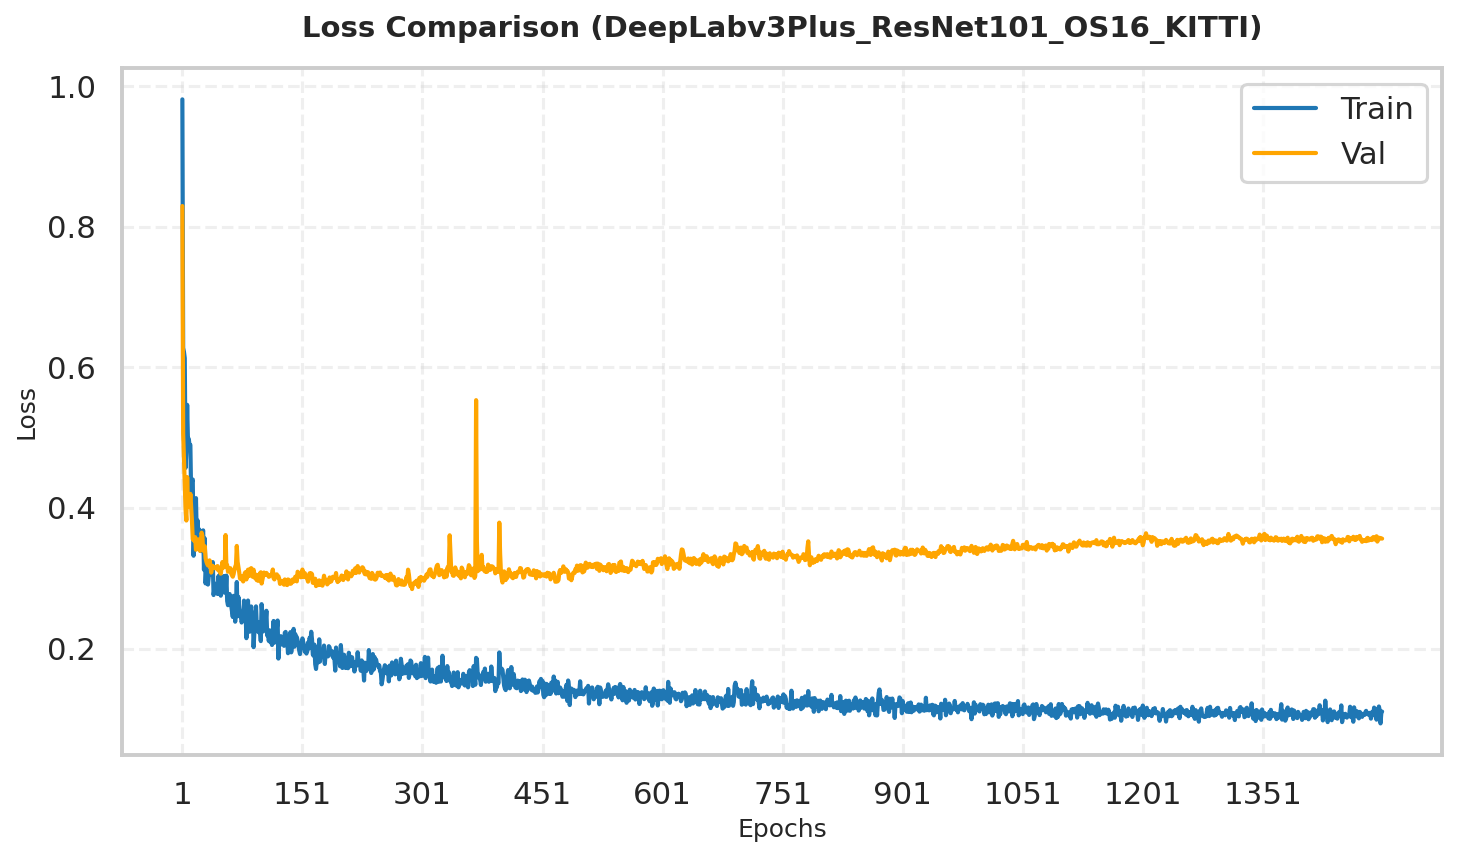

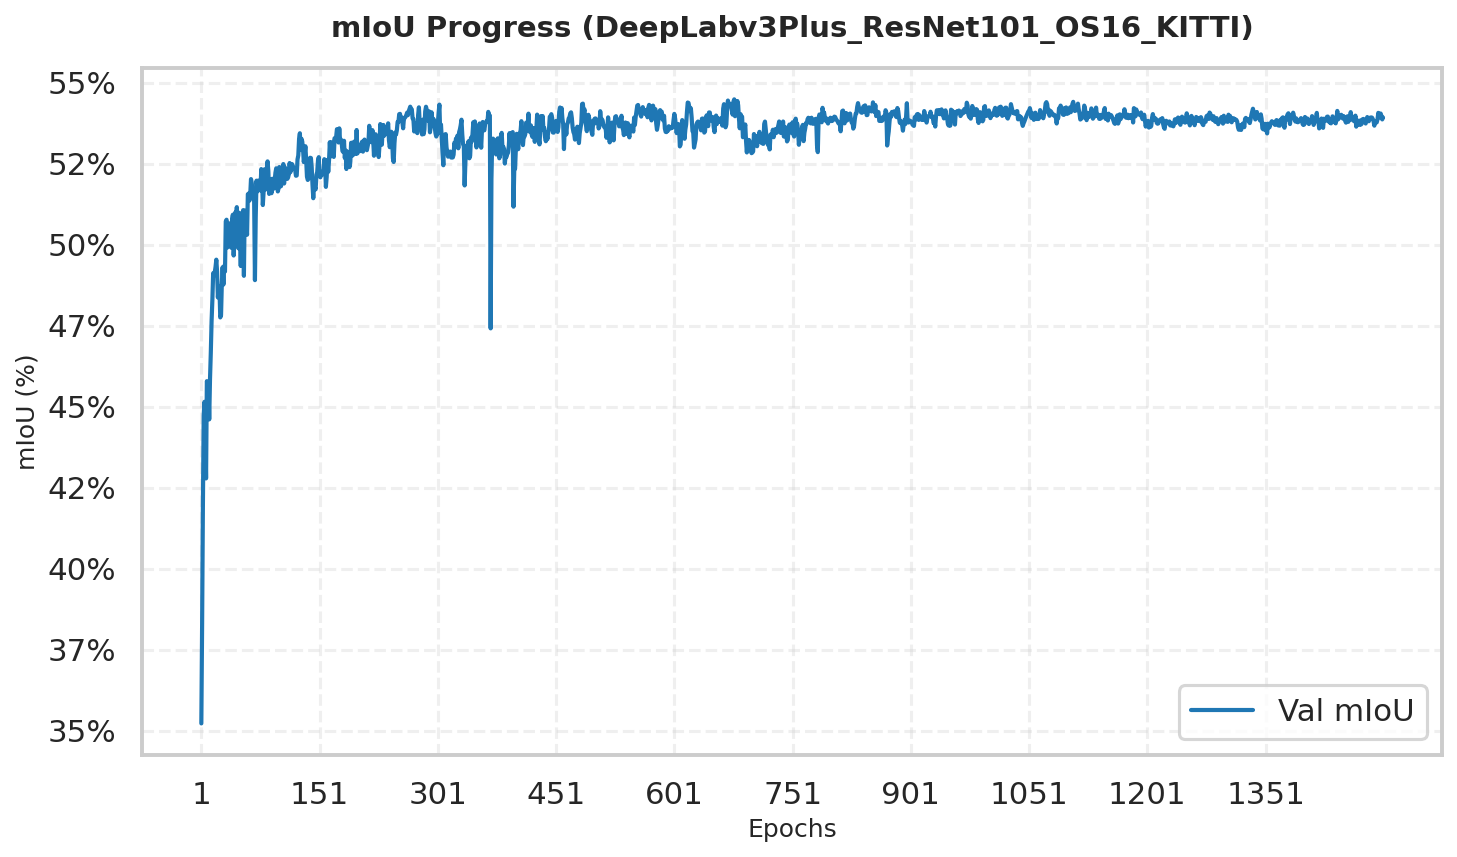

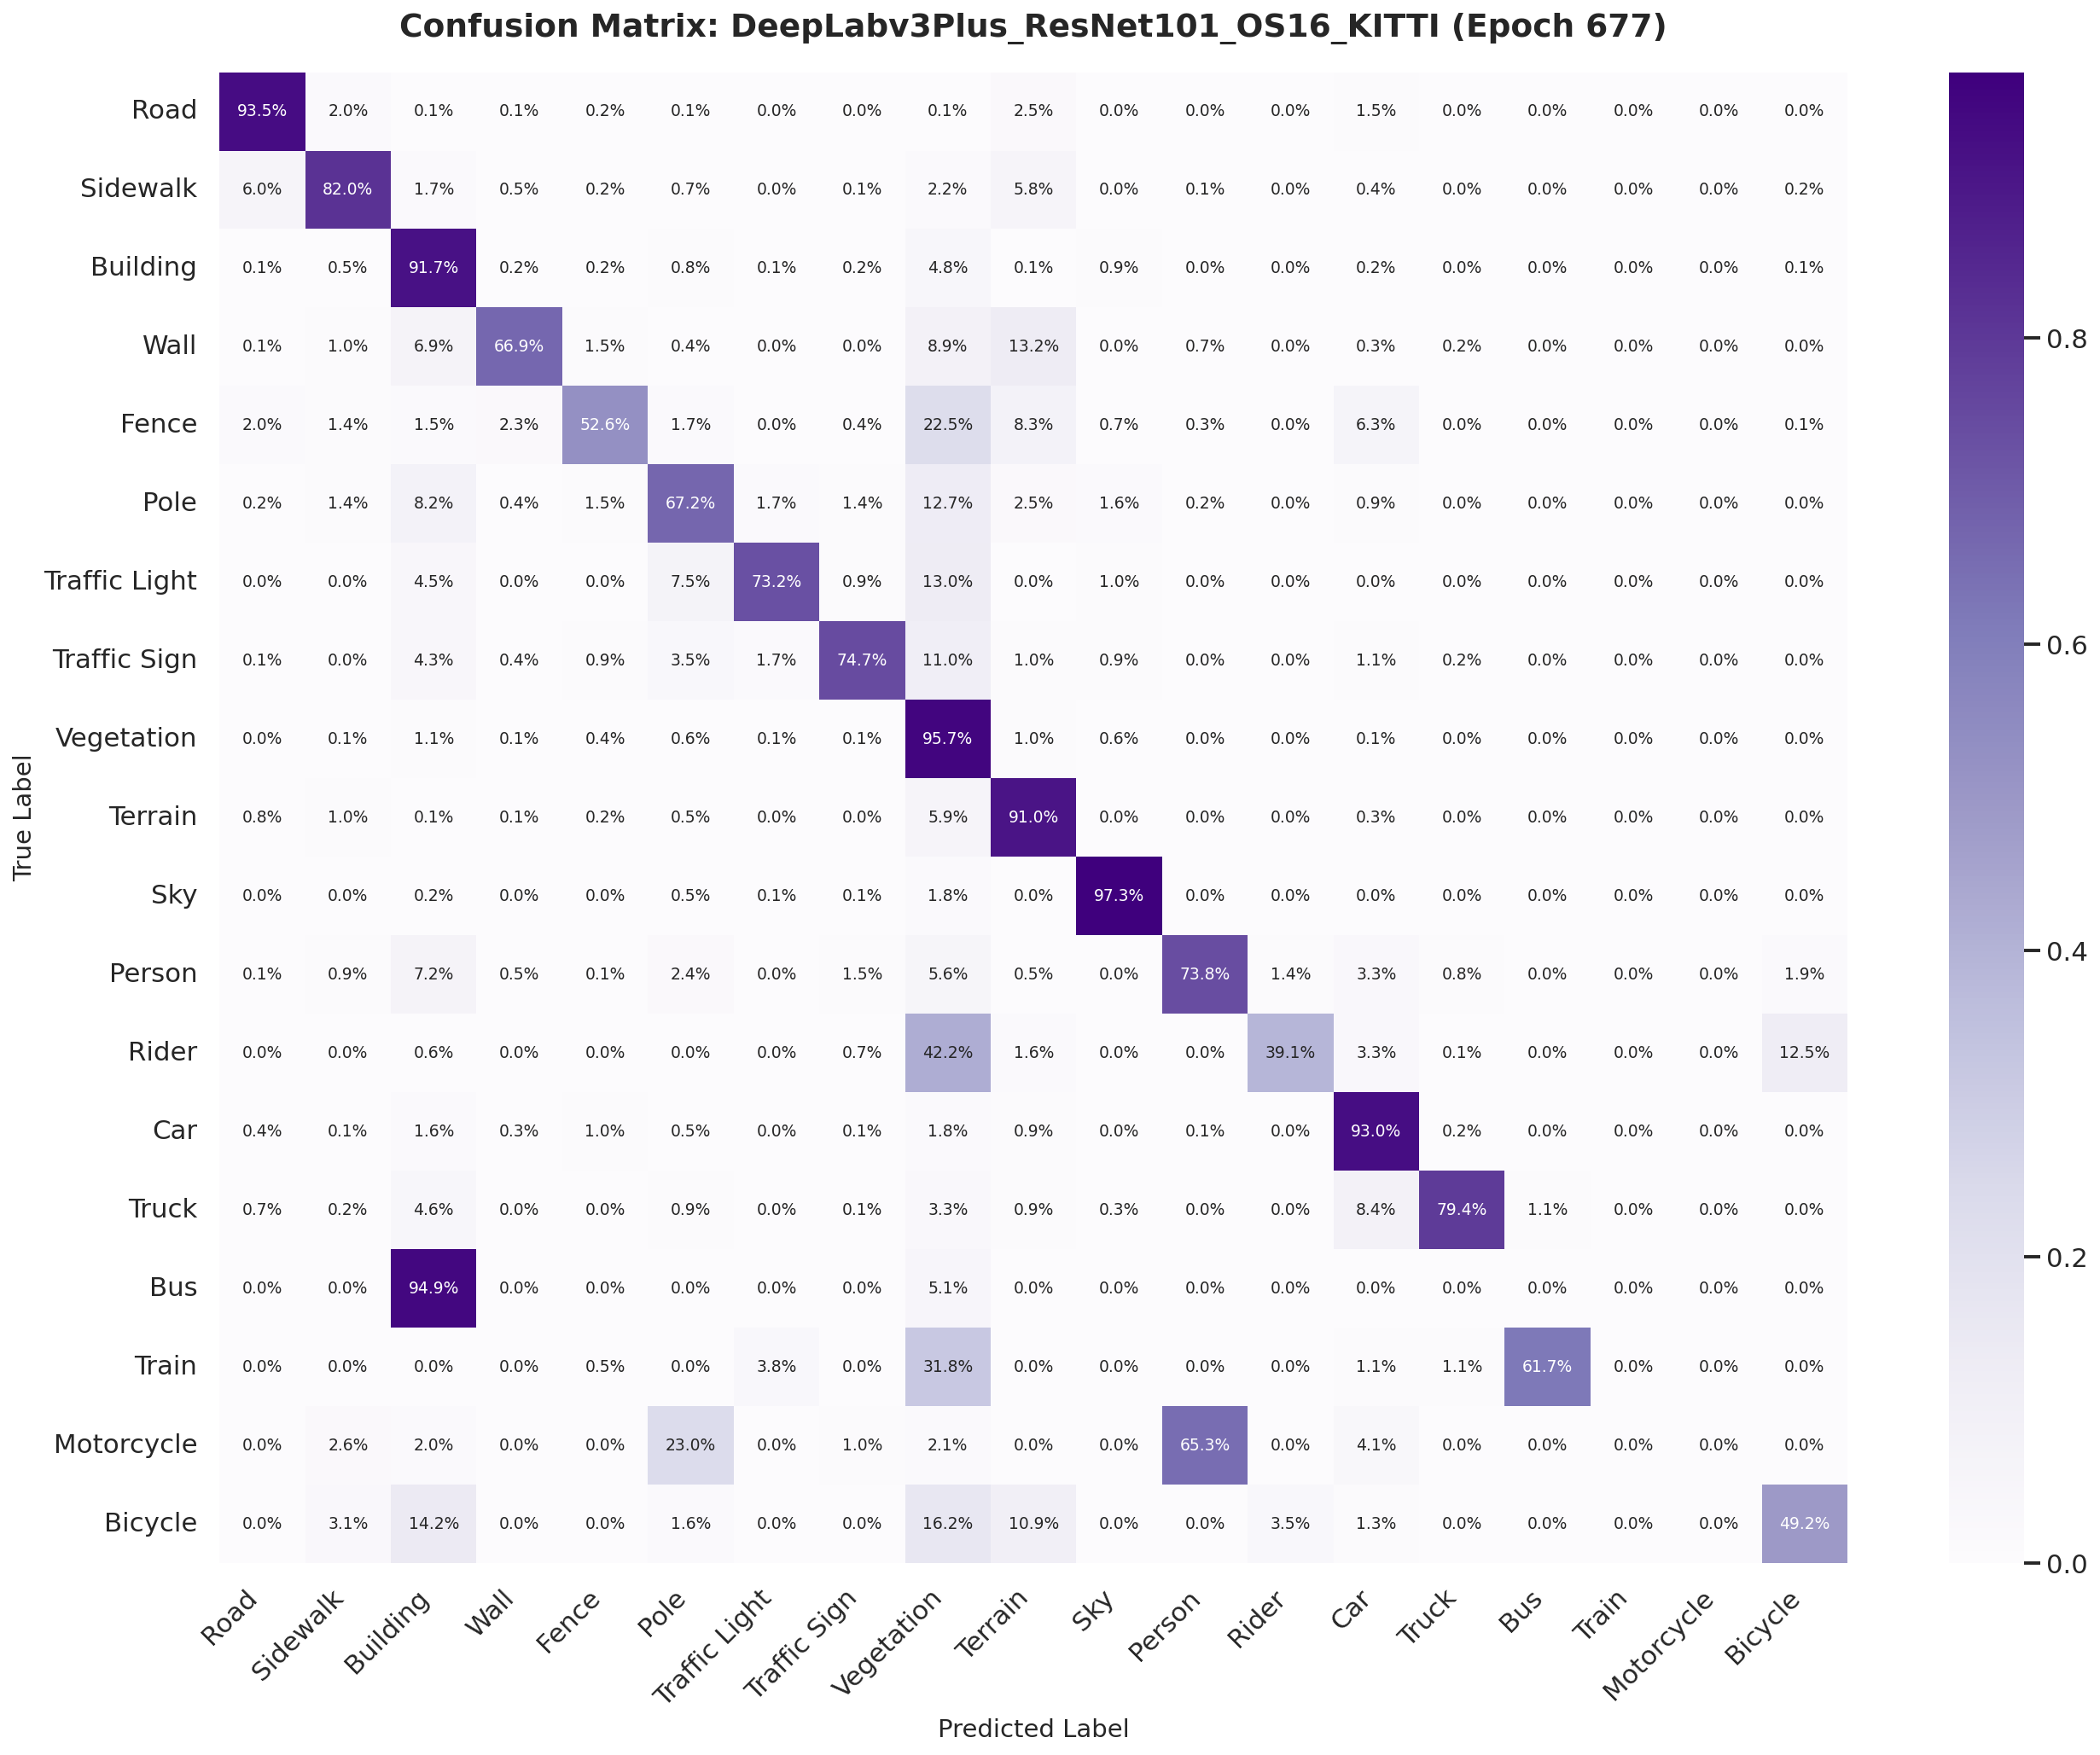


 EXPERIMENT TRACKER: DeepLabv3Plus_ResNet101_OS16_KITTI 
Total Parameters:      45,687,747  (45.69 M)
Trainable Parameters:  45,687,747  (45.69 M)
-------------------------------------------------------------------------------------
Best Validation mIoU:  54.49% (Epoch 677)
Final Epoch aAcc:      92.63%
Final Epoch mAcc:      63.12%
Macro Precision:       68.30%
Macro Recall:          64.23%
Macro F1-Score:        64.30%
-------------------------------------------------------------------------------------
CLASS NAME         | IoU (%)  | Acc (%)  | Prec (%) | Rec (%)  | F1 (%)  
-------------------------------------------------------------------------------------
Road               | 92.05    | 93.50    | 98.34    | 93.50    | 95.86   
Sidewalk           | 69.54    | 81.95    | 82.12    | 81.95    | 82.04   
Building           | 84.99    | 91.71    | 92.06    | 91.71    | 91.88   
Wall               | 58.65    | 66.90    | 82.63    | 66.90    | 73.94   
Fence              | 32.56    | 

In [7]:
# ============================================================
# STEP 6: EXPERIMENT EXPORT & COMPARATIVE TRACKING
# Target Architecture: DeepLabv3+ (Strict Paper Implementation)
# Target Dataset: KITTI Semantic
# Backbone: ResNet-101
# Optimized for: Isolated Run Folders and Master Ledgers
# ============================================================

import os
import json
from pathlib import Path
from datetime import timedelta

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Force Jupyter to display plots inline
%matplotlib inline

# ------------------------------------------------------------
# 1. EXPERIMENT CONFIGURATION
# ------------------------------------------------------------
EXPERIMENT_NAME = "DeepLabv3Plus_ResNet101_OS16_KITTI" 

MANUAL_TOTAL_TIME_STR = None # Auto-calculated from history if None

# ------------------------------------------------------------
# 2. SAFETY CHECKS & ISOLATED PATHS
# ------------------------------------------------------------
required_globals = [
    "history", "model", "CLASS_NAMES", "CLASSES",
    "CHECKPOINT_DIR", "best_record", "DEVICE"
]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required variables from previous steps: {missing}")

# Directed to use FINAL_SAVE_DIR for export routing
MASTER_SAVE_DIR = globals().get("FINAL_SAVE_DIR", Path("./Results_Export"))
RUN_SAVE_DIR = MASTER_SAVE_DIR / EXPERIMENT_NAME

MASTER_SAVE_DIR.mkdir(parents=True, exist_ok=True)
RUN_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"[*] Master Directory: {MASTER_SAVE_DIR.resolve()}")
print(f"[*] Current Run Directory:     {RUN_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# 3. ROBUST METRICS & MATRIX RECOVERY 
# ------------------------------------------------------------
def compute_metrics_fallback(conf_matrix: np.ndarray):
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp
    
    # Calculate IoU safely (outputs NaN if class is absent in both GT and Predictions)
    union = tp + fp + fn
    iou_per_class = np.divide(tp, union, out=np.full_like(tp, np.nan, dtype=float), where=(union > 0))
    mIoU = np.nanmean(iou_per_class)
    
    # Calculate Accuracy safely
    class_total = tp + fn
    acc_per_class = np.divide(tp, class_total, out=np.full_like(tp, np.nan, dtype=float), where=(class_total > 0))
    mAcc = np.nanmean(acc_per_class)
    
    # Global Accuracy
    total_valid = conf_matrix.sum()
    aAcc = np.sum(tp) / (total_valid + 1e-10)
    
    return {
        "mIoU": float(mIoU), 
        "aAcc": float(aAcc), 
        "mAcc": float(mAcc), 
        "iou_per_class": iou_per_class, 
        "acc_per_class": acc_per_class
    }

def compute_f1_precision_recall(conf_matrix: np.ndarray):
    """
    Calculates class-wise and macro-averaged Precision, Recall, and F1-Score 
    safely handling absent classes using np.divide and NaN masking.
    """
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp
    
    # Calculate Precision safely (outputs NaN if TP+FP is 0)
    pred_total = tp + fp
    precision_per_class = np.divide(tp, pred_total, out=np.full_like(tp, np.nan, dtype=float), where=(pred_total > 0))
    
    # Calculate Recall safely (outputs NaN if TP+FN is 0)
    gt_total = tp + fn
    recall_per_class = np.divide(tp, gt_total, out=np.full_like(tp, np.nan, dtype=float), where=(gt_total > 0))
    
    # Calculate F1 safely (outputs NaN if 2*TP+FP+FN is 0)
    f1_denom = (2 * tp) + fp + fn
    f1_per_class = np.divide(2 * tp, f1_denom, out=np.full_like(tp, np.nan, dtype=float), where=(f1_denom > 0))
    
    macro_precision = np.nanmean(precision_per_class)
    macro_recall = np.nanmean(recall_per_class)
    macro_f1 = np.nanmean(f1_per_class)
    
    return {
        "precision_per_class": precision_per_class,
        "recall_per_class": recall_per_class,
        "f1_per_class": f1_per_class,
        "macro_precision": float(macro_precision),
        "macro_recall": float(macro_recall),
        "macro_f1": float(macro_f1)
    }

# Force extraction of the best or latest matrix to guarantee class-wise metrics
matrix_to_use = globals().get("BEST_CONF_MATRIX", globals().get("val_conf_matrix"))

if matrix_to_use is not None:
    # Ensure it's a numpy array for the fallback calculation
    if torch.is_tensor(matrix_to_use):
        matrix_to_use = matrix_to_use.cpu().numpy()
        
    BEST_CONF_MATRIX = matrix_to_use
    BEST_METRICS = compute_metrics_fallback(BEST_CONF_MATRIX)
    
    # Inject F1, Precision, and Recall into the main metrics dictionary
    extra_metrics = compute_f1_precision_recall(BEST_CONF_MATRIX)
    BEST_METRICS.update(extra_metrics)
    
    print("[*] Successfully generated comprehensive class-wise metrics from memory.")
else:
    BEST_CONF_MATRIX = None
    BEST_METRICS = None
    print("[!] Warning: No confusion matrix found in memory. Class-wise data cannot be generated.")

# ------------------------------------------------------------
# 4. BUILD MAIN DATAFRAME
# ------------------------------------------------------------
num_epochs = len(history.get("epoch", []))
if num_epochs == 0:
    num_epochs = len(history.get("train_total_loss", []))

def get_hist_col(keys):
    """Checks multiple possible dictionary keys to guarantee data is found"""
    if isinstance(keys, str): keys = [keys]
    for key in keys:
        col = history.get(key, [])
        if len(col) > 0:
            if len(col) == num_epochs: return col
            return col + [np.nan] * (num_epochs - len(col)) if len(col) < num_epochs else col[:num_epochs]
    return [np.nan] * num_epochs

df = pd.DataFrame({
    "Epoch": get_hist_col("epoch"),
    "Train_Loss": get_hist_col("train_total_loss"),
    "Val_Loss": get_hist_col("val_total_loss"),
    "Train_mIoU": get_hist_col("train_miou"),
    "Val_mIoU": get_hist_col("val_miou"),
    "Val_mAcc": get_hist_col("val_macc"),
    "Val_aAcc": get_hist_col("val_aacc"),
    "Learning_Rate": get_hist_col("learning_rate"),
    "Epoch_Time_sec": get_hist_col("epoch_time_sec"),
})

if df["Epoch"].isna().all() and num_epochs > 0:
    df["Epoch"] = list(range(1, num_epochs + 1))

total_time_str = MANUAL_TOTAL_TIME_STR if MANUAL_TOTAL_TIME_STR else str(timedelta(seconds=int(df["Epoch_Time_sec"].sum(skipna=True))))
df["Total_Training_Session_Time"] = total_time_str

# ------------------------------------------------------------
# 5. PREPARE CLASS-WISE DATA
# ------------------------------------------------------------
class_wise_data = []
if BEST_METRICS is not None and "iou_per_class" in BEST_METRICS:
    for i, name in enumerate(CLASS_NAMES):
        class_wise_data.append({
            "Class Name": name,
            "IoU (%)": BEST_METRICS["iou_per_class"][i] * 100,
            "Accuracy (%)": BEST_METRICS["acc_per_class"][i] * 100,
            "Precision (%)": BEST_METRICS["precision_per_class"][i] * 100,
            "Recall (%)": BEST_METRICS["recall_per_class"][i] * 100,
            "F1-Score (%)": BEST_METRICS["f1_per_class"][i] * 100
        })

# ------------------------------------------------------------
# 6. UPDATE MASTER EXPERIMENT LEDGER
# ------------------------------------------------------------
def safe_pct(val):
    if pd.isna(val) or np.isnan(val): return 0.0
    return val if val > 1.0 else val * 100.0

final_v_acc = safe_pct(df["Val_aAcc"].iloc[-1]) if not df["Val_aAcc"].isna().all() else 0.0
final_mIoU = safe_pct(df["Val_mIoU"].iloc[-1]) if not df["Val_mIoU"].isna().all() else 0.0
final_mAcc = safe_pct(df["Val_mAcc"].iloc[-1]) if not df["Val_mAcc"].isna().all() else 0.0

if "val_miou" in history and len(history["val_miou"]) > 0:
    best_miou_raw = max(history["val_miou"])
    best_idx = history["val_miou"].index(best_miou_raw)
    best_epoch = history.get("epoch", list(range(1, num_epochs + 1)))[best_idx]
    best_miou = safe_pct(best_miou_raw)
else:
    best_epoch = best_record.get("best_epoch", -1)
    best_miou = safe_pct(best_record.get("best_miou", 0.0))

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

macro_prec = safe_pct(BEST_METRICS.get("macro_precision", 0.0)) if BEST_METRICS else 0.0
macro_rec = safe_pct(BEST_METRICS.get("macro_recall", 0.0)) if BEST_METRICS else 0.0
macro_f1 = safe_pct(BEST_METRICS.get("macro_f1", 0.0)) if BEST_METRICS else 0.0

# Create the summary dictionary for this specific run
run_summary = {
    "Experiment Name": EXPERIMENT_NAME,
    "Architecture": "DeepLabv3+",
    "Backbone": "ResNet-101",
    "Best Epoch": best_epoch,
    "Best Val mIoU (%)": round(best_miou, 2),
    "Final aAcc (%)": round(final_v_acc, 2),
    "Final mAcc (%)": round(final_mAcc, 2),
    "Macro Precision (%)": round(macro_prec, 2),
    "Macro Recall (%)": round(macro_rec, 2),
    "Macro F1 (%)": round(macro_f1, 2),
    "Total Params (M)": round(total_params / 1e6, 2),
    "Train Time": total_time_str
}

# Append to master ledger
ledger_path = MASTER_SAVE_DIR / "master_experiment_ledger.csv"
run_df = pd.DataFrame([run_summary])

if ledger_path.exists():
    master_df = pd.read_csv(ledger_path)
    if EXPERIMENT_NAME in master_df["Experiment Name"].values:
        master_df.set_index("Experiment Name", inplace=True)
        run_df.set_index("Experiment Name", inplace=True)
        master_df.update(run_df)
        master_df.reset_index(inplace=True)
    else:
        master_df = pd.concat([master_df, run_df], ignore_index=True)
    master_df.to_csv(ledger_path, index=False)
else:
    run_df.to_csv(ledger_path, index=False)

# Save detailed run files
run_df.to_csv(RUN_SAVE_DIR / "run_summary.csv", index=False)
try:
    with pd.ExcelWriter(RUN_SAVE_DIR / f"{EXPERIMENT_NAME}_Metrics.xlsx", engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name='Epoch_Metrics', index=False)
        if class_wise_data:
            pd.DataFrame(class_wise_data).to_excel(writer, sheet_name='Class_Wise', index=False)
except ImportError: 
    pass  

# ------------------------------------------------------------
# 7. STANDARD SEPARATE PLOTS (Saved to Run Folder)
# ------------------------------------------------------------
sns.set_style("whitegrid")

def save_and_show_plot(filename, title, ylabel, train_data, val_data=None, label1="Train", label2="Val", filter_warmup=False):
    plt.figure(figsize=(10, 6))
    start_idx = 5 if filter_warmup and len(train_data) > 5 else 0
    epochs_range = list(range(start_idx + 1, len(train_data) + 1))
    
    train_clean = np.array(train_data, dtype=float)[start_idx:]
    plt.plot(epochs_range, train_clean, label=label1, lw=2)
    
    if val_data is not None:
        val_clean = np.array(val_data, dtype=float)[start_idx:]
        if not np.isnan(val_clean).all():
            plt.plot(epochs_range, val_clean, label=label2, lw=2, color='orange')
            
    if "(%)" in ylabel: plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}%".format(int(x))))
    
    # Enforce specific epoch intervals for cleaner presentation
    plt.xticks(np.arange(min(epochs_range), max(epochs_range)+1, max(1, len(epochs_range)//10)))
    
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(RUN_SAVE_DIR / f"{filename}.png", dpi=600, bbox_inches='tight')
    plt.show() 
    plt.close()

train_loss = df["Train_Loss"].tolist()
val_loss = df["Val_Loss"].tolist()

def ensure_pct(series):
    if series.isna().all(): return None
    return [x * 100 if (pd.notna(x) and x <= 1.0) else x for x in series.tolist()]

val_miou = ensure_pct(df["Val_mIoU"])

save_and_show_plot("loss_comparison", f"Loss Comparison ({EXPERIMENT_NAME})", "Loss", train_loss, val_loss)
if val_miou is not None:
    save_and_show_plot("miou_progress", f"mIoU Progress ({EXPERIMENT_NAME})", "mIoU (%)", val_miou, label1="Val mIoU")

# ------------------------------------------------------------
# 8. PERCENTAGE-BASED CONFUSION MATRIX
# ------------------------------------------------------------
if BEST_CONF_MATRIX is not None:
    plt.figure(figsize=(18, 14)) 
    cm_normalized = BEST_CONF_MATRIX.astype('float') / (BEST_CONF_MATRIX.sum(axis=1)[:, np.newaxis] + 1e-10)
    
    # Render with strict percentage formatting
    sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Purples', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, annot_kws={"size": 9}) 
    
    plt.title(f"Confusion Matrix: {EXPERIMENT_NAME} (Epoch {best_epoch})", fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(RUN_SAVE_DIR / "confusion_matrix.png", dpi=600, bbox_inches='tight')
    plt.show() 
    plt.close()

# ------------------------------------------------------------
# 9. FINAL SUMMARY
# ------------------------------------------------------------
print(f"\n" + "="*85)
print(f" EXPERIMENT TRACKER: {EXPERIMENT_NAME} ")
print("="*85)
print(f"Total Parameters:      {total_params:,}  ({total_params/1e6:.2f} M)")
print(f"Trainable Parameters:  {trainable_params:,}  ({trainable_params/1e6:.2f} M)")
print("-" * 85)
print(f"Best Validation mIoU:  {best_miou:.2f}% (Epoch {best_epoch})")
print(f"Final Epoch aAcc:      {final_v_acc:.2f}%")
print(f"Final Epoch mAcc:      {final_mAcc:.2f}%")
print(f"Macro Precision:       {macro_prec:.2f}%")
print(f"Macro Recall:          {macro_rec:.2f}%")
print(f"Macro F1-Score:        {macro_f1:.2f}%")
print("-" * 85)
print(f"{'CLASS NAME':<18} | {'IoU (%)':<8} | {'Acc (%)':<8} | {'Prec (%)':<8} | {'Rec (%)':<8} | {'F1 (%)':<8}")
print("-" * 85)

if class_wise_data:
    for item in class_wise_data:
        # Format nan as "N/A" for cleaner console output
        def fmt_val(v): return f"{v:<8.2f}" if not np.isnan(v) else f"{'N/A':<8}"
        print(f"{item['Class Name']:<18} | {fmt_val(item['IoU (%)'])} | {fmt_val(item['Accuracy (%)'])} | "
              f"{fmt_val(item['Precision (%)'])} | {fmt_val(item['Recall (%)'])} | {fmt_val(item['F1-Score (%)'])}")
else:
    print("[!] No class-wise data available in memory to print.")

print("-" * 85)
print(f"[*] Ledger Updated: {ledger_path.resolve()}")
print(f"[*] Artifacts Saved: {RUN_SAVE_DIR.resolve()}")

[*] Presentation graph will be safely exported to:
/home/ubuntu/Pictures/deeplabv3+_kitti/Results_Export_deeplabv3+_kitti/DeepLabv3Plus_ResNet101_OS16_KITTI
[*] Success! Graph preserved at:
/home/ubuntu/Pictures/deeplabv3+_kitti/Results_Export_deeplabv3+_kitti/DeepLabv3Plus_ResNet101_OS16_KITTI/presentation_metrics_DeepLabv3Plus_ResNet101_OS16_KITTI.png


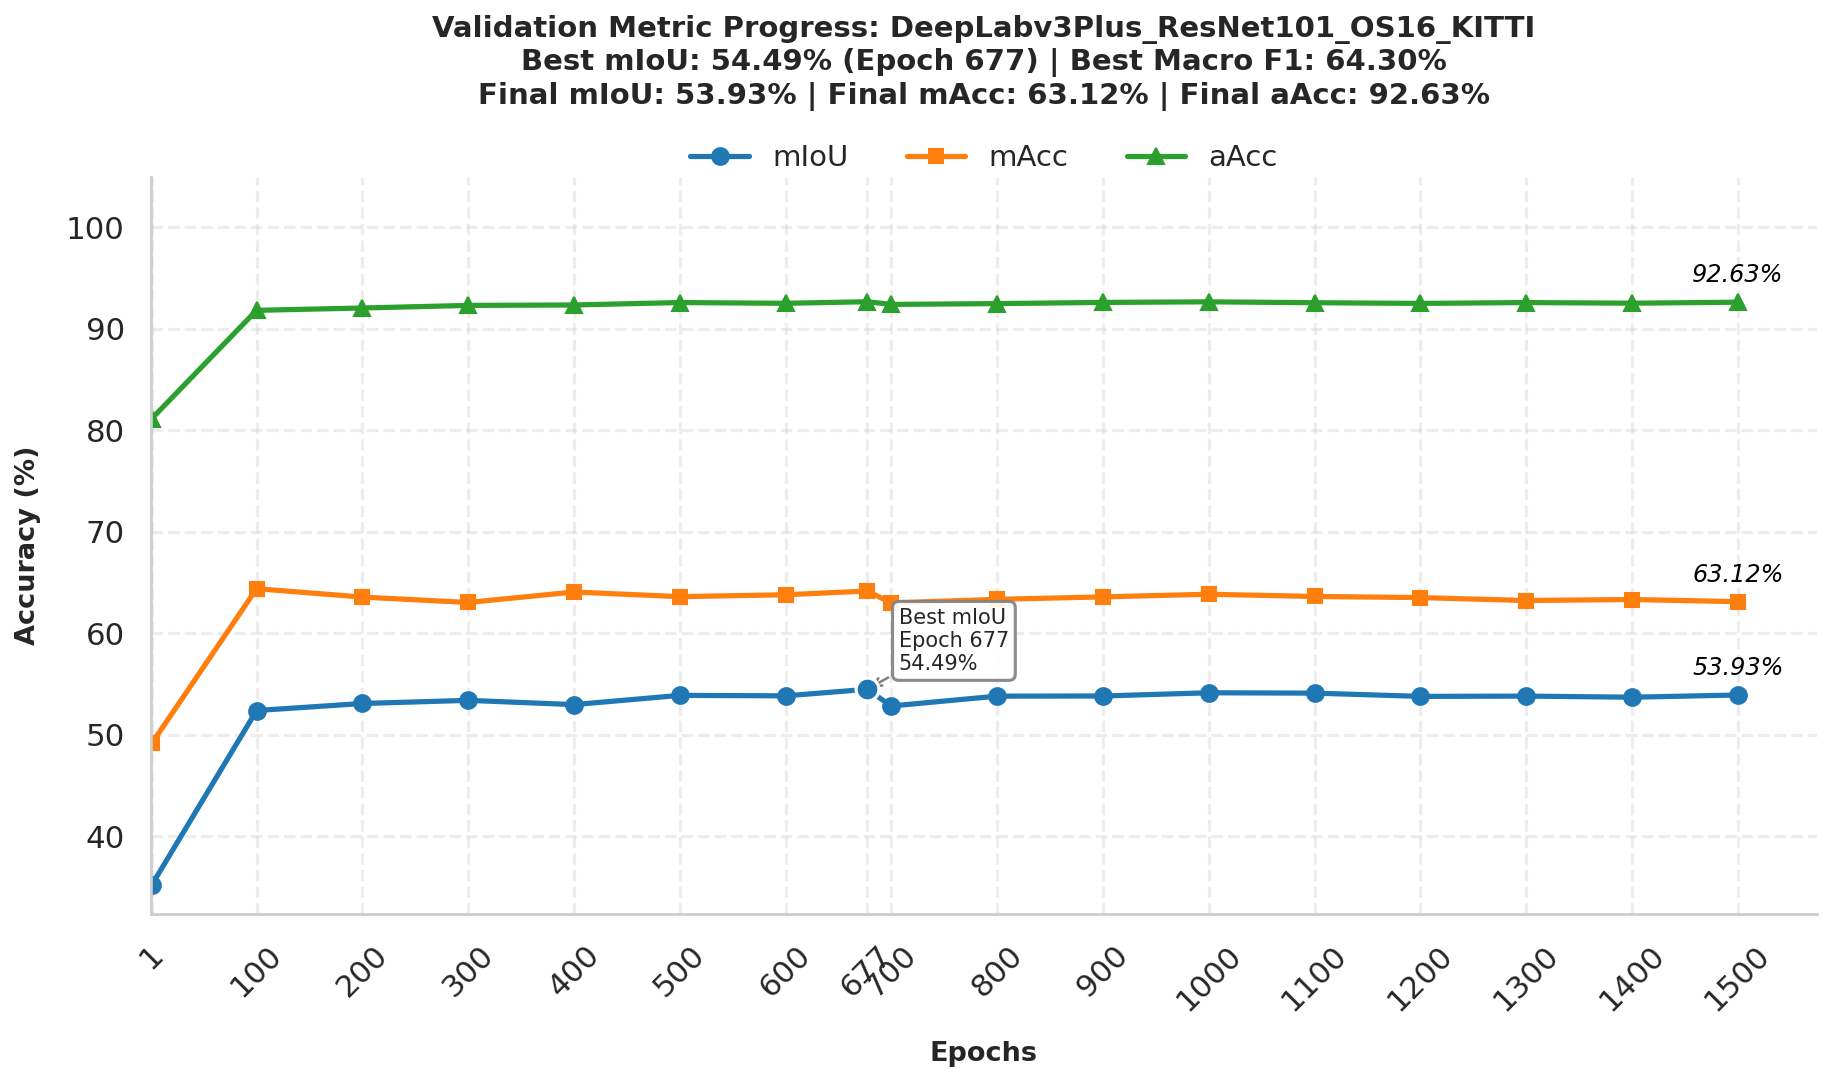

In [8]:
# ============================================================
# STEP 7: PRESENTATION-READY MULTI-METRIC PROGRESS GRAPH
# Target Architecture: DeepLabv3+ (Strict Paper Implementation)
# Backbone: ResNet-101
# Optimized for: Ablation Study Isolation, Specific Epoch Intervals,
# and Strict Percentage Scaling for Publication
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# SAFETY CHECKS & ABLATION PATH INHERITANCE
# ------------------------------------------------------------
required_globals = ["history"]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required variables from previous steps: {missing}")

if "val_miou" not in history or len(history["val_miou"]) == 0:
    raise ValueError("history['val_miou'] is empty. Run training before Step 7.")

# Securely inherit the specific run directory and experiment name from Step 6
EXPERIMENT_NAME = globals().get("EXPERIMENT_NAME", "DeepLabv3Plus_ResNet101_OS16_KITTI")
MASTER_SAVE_DIR = globals().get("FINAL_SAVE_DIR", Path("./Results_Export"))
RUN_SAVE_DIR = globals().get("RUN_SAVE_DIR", MASTER_SAVE_DIR / EXPERIMENT_NAME)

# Ensure the directory exists just in case
RUN_SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"[*] Presentation graph will be safely exported to:\n{RUN_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# PREPARE EPOCHS & DATA
# ------------------------------------------------------------
# Fallback generator if the explicit "epoch" list is missing from older checkpoints
num_epochs = len(history["val_miou"])
all_epochs = history.get("epoch", list(range(1, num_epochs + 1)))

# Safe percentage converter (robust against NaN values)
def safe_pct(val):
    if pd.isna(val) or np.isnan(val): return 0.0
    return val * 100.0 if val <= 1.0 else float(val)

# Bulletproof Best Epoch Extraction
best_miou_raw = max(history["val_miou"])
best_idx = history["val_miou"].index(best_miou_raw)
best_miou = safe_pct(best_miou_raw)
best_miou_epoch = all_epochs[best_idx]

# Dynamically scale the interval to prevent x-axis overcrowding at 1500+ epochs
tick_interval = max(10, num_epochs // 15)

# Filter epochs to reduce visual clutter: Epoch 1, dynamic interval, best epoch, final epoch
filtered_epochs_set = set([e for e in all_epochs if e == 1 or e % tick_interval == 0] + [all_epochs[-1], best_miou_epoch])
filtered_epochs = sorted(list(filtered_epochs_set))

indices = [all_epochs.index(e) for e in filtered_epochs]

# Extract and convert to percentages for cleaner presentation
miou_scores = [safe_pct(history["val_miou"][i]) for i in indices]
macc_scores = [safe_pct(history["val_macc"][i]) for i in indices]
aacc_scores = [safe_pct(history["val_aacc"][i]) for i in indices]

final_miou = safe_pct(history["val_miou"][-1])
final_macc = safe_pct(history["val_macc"][-1])
final_aacc = safe_pct(history["val_aacc"][-1])
final_x = all_epochs[-1]

# ------------------------------------------------------------
# PLOT SETUP 
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12.5, 7.5)) 

color_miou = '#1f77b4'  # Blue
color_macc = '#ff7f0e'  # Orange
color_aacc = '#2ca02c'  # Green

ax.plot(filtered_epochs, miou_scores, marker='o', linewidth=2.5, markersize=8, label='mIoU', color=color_miou)
ax.plot(filtered_epochs, macc_scores, marker='s', linewidth=2.5, markersize=7, label='mAcc', color=color_macc)
ax.plot(filtered_epochs, aacc_scores, marker='^', linewidth=2.5, markersize=8, label='aAcc', color=color_aacc)

# ------------------------------------------------------------
# AXIS LABELS
# ------------------------------------------------------------
ax.set_xlabel('Epochs', fontsize=13, fontweight='bold', labelpad=12)
ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold', labelpad=12)
ax.set_xticks(filtered_epochs)
plt.xticks(rotation=45) # Rotate just in case intervals are tight

# ------------------------------------------------------------
# BEST mIoU ANNOTATION 
# ------------------------------------------------------------
ax.scatter(best_miou_epoch, best_miou, s=120, zorder=5, color=color_miou, edgecolors='white', linewidth=1.5)

if best_miou_epoch <= (max(filtered_epochs) * 0.6):
    best_text_x = best_miou_epoch + (num_epochs * 0.02)
    best_ha = "left"
else:
    best_text_x = best_miou_epoch - (num_epochs * 0.02)
    best_ha = "right"

ax.annotate(
    f'Best mIoU\nEpoch {best_miou_epoch}\n{best_miou:.2f}%',
    xy=(best_miou_epoch, best_miou),
    xytext=(best_text_x, best_miou + 1.5),
    fontsize=10, ha=best_ha, va='bottom',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2)
)

# ------------------------------------------------------------
# END-OF-LINE FINAL VALUE ANNOTATIONS (Floating above markers)
# ------------------------------------------------------------
offset_y = 1.5

ax.text(final_x, final_miou + offset_y, f'{final_miou:.2f}%', va='bottom', ha='center', fontsize=11.5, fontstyle='italic', color='black')
ax.text(final_x, final_macc + offset_y, f'{final_macc:.2f}%', va='bottom', ha='center', fontsize=11.5, fontstyle='italic', color='black')
ax.text(final_x, final_aacc + offset_y, f'{final_aacc:.2f}%', va='bottom', ha='center', fontsize=11.5, fontstyle='italic', color='black')

ax.set_xlim(left=0, right=max(all_epochs) + (max(all_epochs) * 0.05))
ax.set_ylim(top=105) 

# ------------------------------------------------------------
# STYLING & LEGEND
# ------------------------------------------------------------
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=3, frameon=False, fontsize=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.3)
ax.spines['left'].set_linewidth(1.3)

ax.grid(True, linestyle='--', alpha=0.35)

# Dynamically injecting the specific EXPERIMENT_NAME and new F1 Metric into the title
macro_f1_str = ""
if "BEST_METRICS" in globals() and "macro_f1" in BEST_METRICS:
    macro_f1_str = f" | Best Macro F1: {BEST_METRICS['macro_f1'] * 100:.2f}%"

title_main = f"Validation Metric Progress: {EXPERIMENT_NAME}"
title_sub = f"Best mIoU: {best_miou:.2f}% (Epoch {best_miou_epoch}){macro_f1_str}\nFinal mIoU: {final_miou:.2f}% | Final mAcc: {final_macc:.2f}% | Final aAcc: {final_aacc:.2f}%"

ax.set_title(
    title_main + "\n" + title_sub,
    fontsize=14, fontweight='bold', pad=35
)

plt.tight_layout()

# ------------------------------------------------------------
# ISOLATED RUN SAVE (Overrides to FINAL_SAVE_DIR per ledger rules)
# ------------------------------------------------------------
combined_graph_path = RUN_SAVE_DIR / f"presentation_metrics_{EXPERIMENT_NAME}.png"
plt.savefig(combined_graph_path, dpi=600, bbox_inches='tight')
print(f"[*] Success! Graph preserved at:\n{combined_graph_path.resolve()}")

plt.show()
plt.close()